# 4. Prefill–Decode Disaggregation

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

Lecture 3 showed that prefills and decodes interfere when they share a GPU, and
that chunked prefill tames the interference by cutting prompts into pieces. But
it does not remove it: every step that carries a prefill chunk is slower than a
plain decode step (~105 ms instead of ~40 ms in lecture 3), and `chunk_size`
only lets us choose *which* latency to sacrifice, TTFT or TBT.

This lecture explores a more radical idea: **never let the two phases share a
GPU at all.** Run prefills on one set of GPUs and decodes on another, and move
each request from the first to the second once its prompt has been processed.
This is **prefill–decode (PD) disaggregation**, proposed by DistServe (Zhong et
al., OSDI '24) and Splitwise (Patel et al., ISCA '24), and used in production
systems such as Mooncake (Qin et al., FAST '25) and NVIDIA
[Dynamo](https://github.com/ai-dynamo/dynamo).

Throughout the lecture we compare it with the chunked-prefill setup from
lecture 3, on the same number of GPUs, and look for the cases where each one wins.

:::{admonition} Learning goals
- Explain how PD disaggregation removes prefill–decode interference, and what a
  request's journey through a disaggregated cluster looks like.
- Explain why disaggregation helps TPOT/TBT but can hurt TTFT and capacity, and
  why the prefill:decode GPU ratio matters so much.
- Decide, for a given workload, whether chunked prefill or PD disaggregation is
  the better choice.
:::

## Setup

Same setup as {doc}`03-chunked-prefill`: Qwen2.5-32B-Instruct, with each copy of
the model (a **replica**) running on two A100s.

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:  # outside the course repo (e.g. Colab): fetch the package
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

SYSTEM = dict(model="Qwen/Qwen2.5-32B-Instruct", device="a100", tensor_parallel=2)

Simulator ready at /home/user/.llm-systems-wo-gpus/backend


## How disaggregation works

A disaggregated cluster has two **pools** of replicas:

- **Prefill replicas** only run prefills. A new request goes here first. Once its
  prompt is processed, the prefill replica has produced the first token (so TTFT
  is decided here) and has built the request's KV cache.
- **Decode replicas** only run decode steps. The request's **KV cache is
  transferred** from the prefill replica to a decode replica over the network
  between GPUs, and the request then decodes there until it finishes.

Because decode replicas never run prefill work, decoding users keep receiving
tokens at the pace of a plain decode step, whatever prompts other users send.

This has a cost. With chunked prefill, the GPUs that hold the decoding requests
also process prefills, and the decodes ride along almost for free (lecture 3).
With disaggregation, prefills can only use the prefill GPUs: if those are busy, a
new request waits, even when the decode GPUs have spare compute. **We trade
interference for a fixed split of the hardware.**

## Describing a disaggregated cluster

`lsg.simulate` accepts a `replica_groups` description of the cluster: a list of
replica groups, each with a role (`"prefill"` or `"decode"`), a number of
replicas, and their configuration, plus a "pool" that says which prefill replicas
hand requests to which decode replicas. The helper below builds one, with a TP=2
replica (two A100s) as the unit, so that every configuration we compare uses
whole replicas.

One more detail: with disaggregation, the cluster needs a router that knows about
the two pools (`global_scheduler="load_aware"`), which sends each new request to
the least-loaded prefill replica and then to a decode replica with room for it.

In [2]:
def pd_cluster(n_prefill, n_decode, prefill_chunk_size=4096):
    """n_prefill prefill replicas and n_decode decode replicas, each on two A100s."""
    def group(role, n, chunk_size):
        return {"role": role, "num_replicas": n,
                "replica_config": {"model_name": SYSTEM["model"], "device": SYSTEM["device"],
                                   "tensor_parallel_size": SYSTEM["tensor_parallel"],
                                   "network_device": "a100_dgx", "pd_disaggregation": 1},
                "replica_scheduler_config": {"type": "vllm_v1", "batch_size_cap": 128,
                                             "chunk_size": chunk_size}}
    return {"replica_groups": [group("prefill", n_prefill, prefill_chunk_size),
                               group("decode", n_decode, 512)],
            "replica_groups_pools": [{"prefill": list(range(n_prefill)),
                                      "decode": list(range(n_prefill, n_prefill + n_decode)),
                                      "cross_node": False}]}

def run_pd(n_prefill, n_decode, prefill_chunk_size=4096, **kwargs):
    """Simulate a disaggregated cluster."""
    return lsg.simulate(**SYSTEM, replica_groups=pd_cluster(n_prefill, n_decode, prefill_chunk_size),
                        global_scheduler="load_aware", **kwargs)

def run_chunked(n_replicas, **kwargs):
    """Simulate n_replicas ordinary replicas, each doing both phases with chunked prefill."""
    return lsg.simulate(**SYSTEM, num_replicas=n_replicas, chunk_size=512, **kwargs)

## Head to head on four GPUs

We reuse lecture 3's mixed workload: 85% chat turns (256 tokens in, 256 out) and
15% documents (3,800 tokens in, 32 out). With four GPUs we can build:

- **Chunked:** two ordinary replicas, each with chunked prefill (`chunk_size=512`),
  requests alternating between them;
- **PD 1:1:** one prefill replica and one decode replica.

In [3]:
def mixed_trace(doc_fraction, n=300, seed=0):
    rng = np.random.default_rng(seed)
    is_doc = rng.random(n) < doc_fraction
    return lsg.make_trace(prefill_tokens=np.where(is_doc, 3800, 256),
                          decode_tokens=np.where(is_doc, 32, 256), n=n,
                          name=f"mixed_{doc_fraction}")

trace = mixed_trace(0.15)
cols = ["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "TPOT p99 (ms)", "throughput (tok/s)"]
four = {"chunked (2 replicas)": run_chunked(2, trace=trace, num_requests=300, qps=4, keep_steps=True),
        "PD 1:1": run_pd(1, 1, trace=trace, num_requests=300, qps=4, keep_steps=True)}
pd.DataFrame({k: r.summary()[cols] for k, r in four.items()}).round(0)

,chunked (2 replicas),PD 1:1
TTFT p50 (ms),108.0,289.0
TTFT p99 (ms),1493.0,1924.0
TPOT p50 (ms),48.0,37.0
TPOT p99 (ms),76.0,40.0
throughput (tok/s),3885.0,3880.0


The two designs serve the same throughput, but the latencies move in opposite
directions:

- **TPOT improves a lot.** With disaggregation, p99 TPOT is about half of the
  chunked design's, and barely above p50: every request decodes at the speed of
  a plain decode step. The interference is gone.
- **TTFT gets worse.** The median TTFT is more than twice as long. In the chunked
  design, a new prompt can start on *either* replica; here, all prompts queue for
  the single prefill replica.

We can confirm the first point by looking at the steps each replica ran
(`keep_steps=True`). The longest step on the PD decode replica is a plain decode
step, while the chunked replicas regularly run steps carrying a prefill chunk:

In [4]:
for name, r in four.items():
    st = r.steps
    st["kind"] = np.where(st["batch_num_prefill_tokens"] > 0, "with prefill", "decode only")
    print(name)
    table = st.groupby(["replica", "kind"])["batch_execution_time"].agg(
        steps="count", median_ms="median", longest_ms="max")
    table[["median_ms", "longest_ms"]] = (1e3 * table[["median_ms", "longest_ms"]]).round(0)
    print(table, "\n")

chunked (2 replicas)
                      steps  median_ms  longest_ms
replica kind                                      
0       decode only    1338       38.0        40.0
        with prefill    293      104.0       111.0
1       decode only    1322       38.0        40.0
        with prefill    298      104.0       112.0 

PD 1:1
                      steps  median_ms  longest_ms
replica kind                                      
0       with prefill    206       60.0       709.0
1       decode only    2086       38.0        40.0 



In the PD cluster, replica 0 is the prefill replica, running long prefill steps,
and replica 1 is the decode replica, running only decode steps. That separation is
exactly what keeps TPOT flat.

## Tuning each pool separately

Separating the phases has a second benefit: each pool can be configured for its
own job. In lecture 3 the token budget had to balance two opposing goals. A
prefill replica has no decoding users to protect, so it can use a large budget
and prefill each prompt in as few steps as possible. Compare the prefill pool
with the lecture 3 budget (512) and with a large one (4,096, the default in our
helper):

In [5]:
pd.DataFrame({f"prefill chunk_size={c}": run_pd(1, 1, prefill_chunk_size=c, trace=trace,
                                                num_requests=300, qps=4).summary()[cols]
              for c in (512, 4096)}).round(0)

,prefill chunk_size=512,prefill chunk_size=4096
TTFT p50 (ms),563.0,289.0
TTFT p99 (ms),1940.0,1924.0
TPOT p50 (ms),37.0,37.0
TPOT p99 (ms),40.0,40.0
throughput (tok/s),3884.0,3880.0


The large budget almost halves the median TTFT, at no cost in TPOT. The same idea
goes further in real systems: the two pools can use different parallelism, or
even different GPU types, each chosen for compute-bound prefill or memory-bound
decode.

## Under increasing load

Let's sweep the arrival rate for both four-GPU designs.

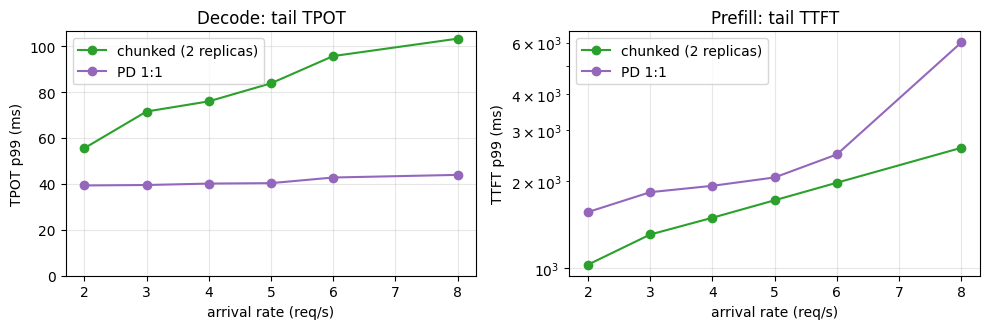

In [6]:
loads = [2, 3, 4, 5, 6, 8]
sweep = {"chunked (2 replicas)": lsg.sweep("qps", loads, **SYSTEM, num_replicas=2, chunk_size=512,
                                           trace=trace, num_requests=300),
         "PD 1:1": pd.DataFrame([run_pd(1, 1, trace=trace, num_requests=300, qps=q).summary()
                                 for q in loads], index=pd.Index(loads, name="qps"))}

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for (name, df), color in zip(sweep.items(), ("C2", "C4")):
    ax[0].plot(df.index, df["TPOT p99 (ms)"], "o-", color=color, label=name)
    ax[1].plot(df.index, df["TTFT p99 (ms)"], "o-", color=color, label=name)
ax[0].set(xlabel="arrival rate (req/s)", ylabel="TPOT p99 (ms)", title="Decode: tail TPOT",
          ylim=(0, None))
ax[1].set(xlabel="arrival rate (req/s)", ylabel="TTFT p99 (ms)", title="Prefill: tail TTFT",
          yscale="log")
for a in ax:
    a.legend()
fig.tight_layout()

Disaggregation keeps TPOT flat at every load, while the chunked design's tail TPOT
grows steadily as more prefill chunks land in decode steps. TTFT tells the opposite
story: the single prefill replica saturates first, and at 8 req/s its queue grows
so long that TTFT reaches several seconds, while the chunked design, which can
prefill on all four GPUs, is still below three seconds.

So which design is better depends on what you care about. If your users mostly
stream long answers and complain about stutter, disaggregation is attractive. If
they mostly care about how quickly the answer starts, or the cluster runs hot,
the chunked design uses the hardware more flexibly.

## The ratio matters: eight GPUs

With four GPUs, the only possible split was 1:1. Real deployments choose how many
replicas to devote to each phase. With eight GPUs (four replicas), we can compare
the chunked design with three splits. Since the right split depends on the
workload, we run two workloads: our usual one (15% documents) and a
document-heavy one (40% documents), both at 8 req/s.

In [7]:
designs = {"chunked (4 replicas)": lambda **kw: run_chunked(4, **kw),
           "PD 1:3": lambda **kw: run_pd(1, 3, **kw),
           "PD 2:2": lambda **kw: run_pd(2, 2, **kw),
           "PD 3:1": lambda **kw: run_pd(3, 1, **kw)}
ratio = {}
for frac in (0.15, 0.40):
    t = mixed_trace(frac)
    for name, run in designs.items():
        ratio[(f"{frac:.0%} documents", name)] = run(trace=t, num_requests=300, qps=8).summary()[cols]
ratio = pd.DataFrame(ratio).T
ratio.round(0)

TTFT p50 (ms)  TTFT p99 (ms)  \
15% documents chunked (4 replicas)          102.0         1266.0   
              PD 1:3                       3612.0         6011.0   
              PD 2:2                         99.0         1182.0   
              PD 3:1                         60.0          688.0   
40% documents chunked (4 replicas)          835.0         2560.0   
              PD 1:3                      20798.0        39322.0   
              PD 2:2                       3436.0         5313.0   
              PD 3:1                        535.0         1356.0   

                                    TPOT p50 (ms)  TPOT p99 (ms)  \
15% documents chunked (4 replicas)           47.0           75.0   
              PD 1:3                         42.0           44.0   
              PD 2:2                         42.0           43.0   
              PD 3:1                         42.0           44.0   
40% documents chunked (4 replicas)           65.0          104.0   
              PD 1:3                         38.0           40.0   
              PD 2:2                         40.0           43.0   
              PD 3:1                         41.0           44.0   

                                    throughput (tok/s)  
15% documents chunked (4 replicas)              6910.0  
              PD 1:3                            6133.0  
              PD 2:2                            6824.0  
              PD 3:1                            6828.0  
40% documents chunked (4 replicas)             11228.0  
              PD 1:3                            5953.0  
              PD 2:2                           10382.0  
              PD 3:1                           11152.0

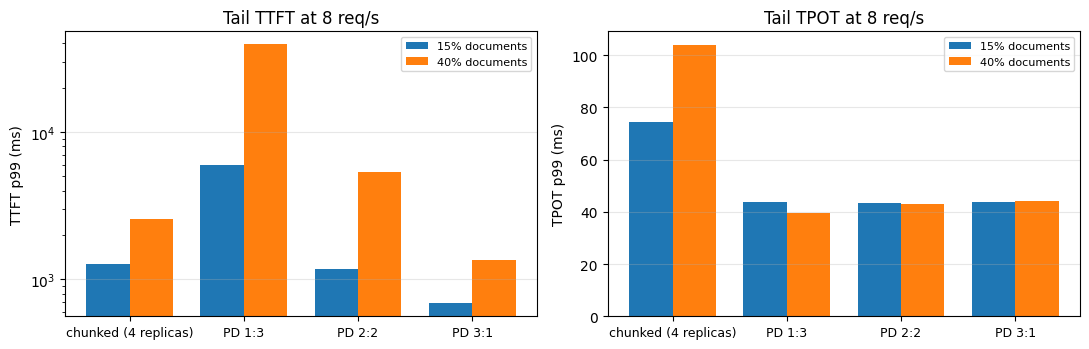

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
workloads = ratio.index.get_level_values(0).unique()
x = np.arange(len(designs))
for i, (w, color) in enumerate(zip(workloads, ("C0", "C1"))):
    sub = ratio.loc[w]
    ax[0].bar(x + (i - 0.5) * 0.38, sub["TTFT p99 (ms)"], 0.38, color=color, label=w)
    ax[1].bar(x + (i - 0.5) * 0.38, sub["TPOT p99 (ms)"], 0.38, color=color, label=w)
ax[0].set(ylabel="TTFT p99 (ms)", yscale="log", title="Tail TTFT at 8 req/s")
ax[1].set(ylabel="TPOT p99 (ms)", title="Tail TPOT at 8 req/s")
for a in ax:
    a.set_xticks(x, list(designs), fontsize=9)
    a.legend(fontsize=8)
    a.grid(axis="x", visible=False)
fig.tight_layout()

Three lessons:

1. **With the right split, disaggregation wins on both metrics.** For the usual
   workload, PD 3:1 has a lower tail TTFT *and* a much lower tail TPOT than the
   chunked design on the same eight GPUs. Prefill is the expensive phase here
   (one 3,800-token prompt costs as much compute as hundreds of decode tokens), so
   it deserves most of the GPUs.
2. **With the wrong split, it loses badly.** PD 1:3 starves the prefill pool and
   TTFT explodes into seconds (tens of seconds with more documents), while its
   three decode replicas have far more capacity than the workload needs.
3. **The right split depends on the workload.** PD 2:2 is fine for the usual
   workload, but when the share of documents rises to 40%, its TTFT jumps into
   seconds. The chunked design degrades gracefully instead, because any GPU can do
   any work. A real deployment whose traffic mix changes during the day must
   either re-balance its pools or accept periods of imbalance.

## When there is nothing to protect

Disaggregation exists to keep long prefills away from decodes. What if the prompts
are all short? Let's run only chat turns on four GPUs and also measure how busy
each replica is (the fraction of time it spends running steps).

In [9]:
chat = mixed_trace(0.0)
rows = {}
for name, r in {"chunked (2 replicas)": run_chunked(2, trace=chat, num_requests=300, qps=8, keep_steps=True),
                "PD 1:1": run_pd(1, 1, trace=chat, num_requests=300, qps=8, keep_steps=True)}.items():
    s = r.summary()
    busy = r.steps.groupby("replica")["batch_execution_time"].sum() / s["makespan (s)"]
    rows[name] = {**s[cols].round(0).to_dict(),
                  **{f"replica {k} busy": f"{v:.0%}" for k, v in busy.items()}}
pd.DataFrame(rows)

,chunked (2 replicas),PD 1:1
TTFT p50 (ms),100.0,60.0
TTFT p99 (ms),189.0,254.0
TPOT p50 (ms),47.0,42.0
TPOT p99 (ms),48.0,42.0
throughput (tok/s),3501.0,3457.0
replica 0 busy,99%,39%
replica 1 busy,99%,99%


With short prompts, the chunked design has very little interference to begin
with, so disaggregation improves TPOT only slightly, and its tail TTFT is worse. Meanwhile, the PD prefill replica is
idle most of the time: two of the four GPUs mostly wait for work, while the
single decode replica carries all decode work alone. As the load grows further,
that decode replica fills up first, while the chunked design can still spread
decodes over all four GPUs.

:::{note}
In the simulator, an overloaded decode pool stops the run with an error about
`batch_size_cap` instead of queueing requests. If you see it in the exercises,
lower `qps` or add decode replicas.
:::

## The cost of moving the KV cache

One cost we have not seen yet in the numbers is the **KV-cache transfer**. A
request's KV cache has to travel from the prefill replica to the decode replica.
For our model, each token's KV cache takes 256 KB (lecture 2), so:

In [10]:
kv_per_token = 2 * 64 * 8 * 128 * 2          # K and V x layers x KV heads x head dim x 2 bytes
links = {"NVLink inside a server (~300 GB/s)": 300e9,
         "InfiniBand between servers (~25 GB/s per GPU)": 25e9,
         "100 Gb/s Ethernet (~12.5 GB/s)": 12.5e9}
pd.DataFrame({f"{n:,}-token prompt": {name: f"{1e3 * n * kv_per_token / bw:.0f} ms"
                                        for name, bw in links.items()}
              for n in (256, 3800, 16000)})

,256-token prompt,"3,800-token prompt","16,000-token prompt"
NVLink inside a server (~300 GB/s),0 ms,3 ms,14 ms
InfiniBand between servers (~25 GB/s per GPU),3 ms,40 ms,168 ms
100 Gb/s Ethernet (~12.5 GB/s),5 ms,80 ms,336 ms


(These numbers assume the whole KV cache crosses one link; with TP=2, each GPU
sends its half in parallel.) Over a fast link inside a server, the transfer takes
a few milliseconds. Between servers, a long prompt's KV cache takes tens to
hundreds of milliseconds to move. That is still much shorter than the prefill
that produced it (~650 ms for 3,800 tokens), so real systems hide most of it by
**streaming** the KV cache layer by layer while the prefill is still running. The
simulator assumes the same overlap, which is why the transfer did not show up in
our results. With slower networks or less overlap, though, the transfer adds
directly to the time before the second token, and it always consumes network
bandwidth that the cluster may need for other traffic.

## Summary: chunked prefill or disaggregation?

| | Chunked prefill (lecture 3) | PD disaggregation |
|---|---|---|
| Interference | reduced, controlled by `chunk_size` | eliminated |
| TPOT / TBT tail | grows with load and with long prompts | flat, at the plain decode-step speed |
| TTFT | any replica can prefill | only the prefill pool can prefill; queues if it is undersized |
| Hardware use | any GPU does any work, adapts to the mix | fixed split; one pool can idle while the other is overloaded |
| Tuning | one configuration must balance both phases | each pool configured for its phase (chunk size, parallelism, GPU type) |
| Extra cost | none | KV-cache transfer; needs fast interconnects |
| Best when | short prompts, changing traffic mix, TTFT matters most | long prompts, strict TBT/TPOT targets, stable mix with a well-sized split |

The two are not mutually exclusive: production systems combine them, for example
disaggregating long-context traffic while serving short requests on ordinary
replicas, or using chunked prefill inside the prefill pool.

## Exercises

:::{admonition} Try it
:class: exercise
Each exercise asks you to change code above and rerun it. Write down your
prediction *before* you run.

1. **Find the best split.** In "The ratio matters", add the chat-only workload
   (`mixed_trace(0.0)`) to the two workloads and rerun. Which split is best now?
   Does any PD split beat the chunked design on both TTFT and TPOT?
2. **Goodput.** Suppose your SLO is p99 TTFT < 2 s and p99 TPOT < 60 ms. Using the
   load sweep on four GPUs, find the goodput (lecture 2) of the chunked design and
   of PD 1:1. Then repeat on eight GPUs for the chunked design (4 replicas) and PD
   3:1, adding higher loads to the sweep. Which design wins, and does the answer
   depend on the number of GPUs?
3. **Shorter documents.** Change the document length in `mixed_trace` from 3,800
   to 1,000 tokens and rerun the four-GPU head-to-head. Does disaggregation still
   help TPOT as much? Why?
:::

## Check your understanding

Click an answer to check it. Wrong answers can be retried.

In [11]:
#@title Questions (run this cell)
lsg.quiz([
    {"q": "In a disaggregated cluster, which pool determines a request's TTFT?",
     "options": ["The prefill pool", "The decode pool", "Both equally"], "answer": 0,
     "explain": "The first token is produced at the end of the prefill, on the prefill replica. The decode pool determines the gaps between later tokens."},
    {"q": "Why does PD disaggregation keep TPOT flat even when long prompts arrive?",
     "options": ["The decode replicas use faster GPUs",
                 "Decode steps never contain prefill work, so they are always short",
                 "Long prompts are rejected"],
     "answer": 1,
     "explain": "A step is only as fast as its biggest piece of work. On a decode replica, there is never a prefill chunk in the step."},
    {"q": "On the same four GPUs, PD 1:1 had a worse median TTFT than two chunked replicas. Why?",
     "options": ["The KV-cache transfer is slow",
                 "All prompts queue for the single prefill replica, while in the chunked design either replica can prefill",
                 "Decode replicas cannot produce the first token"],
     "answer": 1,
     "explain": "Disaggregation fixes which GPUs may run prefills. With only one prefill replica, prompts wait for it even when the decode replica has spare compute."},
    {"q": "Why can a prefill replica use a much larger token budget (chunk_size) than a chunked-prefill replica?",
     "options": ["Prefill replicas have more memory",
                 "There are no decoding requests on it whose tokens would be delayed by long steps",
                 "Large chunks reduce the KV-cache size"],
     "answer": 1,
     "explain": "The budget limits step length to protect decoding users. A prefill replica has none, so it can prefill each prompt in as few steps as possible."},
    {"q": "A disaggregated cluster has the right prefill:decode split for today's traffic. Tomorrow, the share of long documents doubles. What is the main risk?",
     "options": ["TPOT increases on the decode pool",
                 "The prefill pool becomes undersized and TTFT explodes",
                 "The KV cache no longer fits"],
     "answer": 1,
     "explain": "More long prompts means more prefill work for the same prefill pool. Unless the pools are re-balanced, prompts queue and TTFT grows, while decode GPUs may sit idle."},
    {"q": "For a workload of only short chat prompts, which design is usually the better choice?",
     "options": ["PD disaggregation", "Chunked prefill on ordinary replicas"], "answer": 1,
     "explain": "Short prompts cause little interference, so there is little to gain, while a fixed prefill pool sits mostly idle."},
    {"q": "Why does the KV-cache transfer usually add little latency in practice?",
     "options": ["The KV cache is tiny",
                 "It is streamed layer by layer while the prefill is still running, over fast interconnects",
                 "It happens after the request finishes"],
     "answer": 1,
     "explain": "A 3,800-token prompt has about 1 GB of KV cache here. Streaming it during the prefill over NVLink or InfiniBand hides most of the transfer; over slow networks it would not be hidden."},
])